In [1]:
# Ensure that we are using the correct host
import socket
try:
    assert "gpu" in socket.gethostname()
    print(f"Running on {socket.gethostname()}. All is good!")
except:
    raise RuntimeError(f"Be sure to run on GPU! You are currently running on {socket.gethostname()}")

Running on gpu39.storrs.hpc.uconn.edu. All is good!


In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
base = "/shared/healthinfolab/datasets/ABCD/Irritability/Clinical_Data/Irritability/Release_5.0/"

files = {
    0:  base + "abcd_cbcl_irr_index_release5.0_0m_long.csv",
    12: base + "abcd_cbcl_irr_index_release5.0_12m_long.csv",
    24: base + "abcd_cbcl_irr_index_release5.0_24m_long.csv",
    36: base + "abcd_cbcl_irr_index_release5.0_36m_long.csv",
    48: base + "abcd_cbcl_irr_index_release5.0_48m_long.csv",
}

In [4]:
dfs = []

for t, path in files.items():
    df = pd.read_csv(path)
    df = df[["src_subject_id", "cbcl_irr_index_cnst"]].copy()
    df["time"] = t
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

In [5]:
data = data.rename(columns={
    "src_subject_id": "id",
    "cbcl_irr_index_cnst": "irr"
})

data = data.dropna()

counts = data.groupby("id").size()
valid_ids = counts[counts >= 2].index
data = data[data["id"].isin(valid_ids)]

In [6]:
# Choose a small subset of subjects for testing
# FIX: set random seed for reproducibility
np.random.seed(42)
subset_size = 500

subset_ids = np.random.choice(
    data["id"].unique(),
    size=subset_size,
    replace=False
)

data = data[data["id"].isin(subset_ids)].copy()

In [7]:
ids = data["id"].unique()
id_map = {v: i for i, v in enumerate(ids)}

data["id_i"] = data["id"].map(id_map)

# FIX: scale time to [0, 1] to improve sampler geometry.
# Raw values 0-48 combined with small slope estimates can cause
# poorly-scaled posterior geometry for NUTS.
time = data["time"].values / 48.0

y = data["irr"].values
person = data["id_i"].values

N = len(ids)

print(f"N subjects: {N}")
print(f"N observations: {len(y)}")
print(f"irr range: [{y.min():.2f}, {y.max():.2f}], mean: {y.mean():.2f}, std: {y.std():.2f}")

N subjects: 500
N observations: 2083
irr range: [0.00, 6.00], mean: 0.84, std: 1.25


## Model Selection: Fit LCGA for K = 2 to 5

LCGA requires comparing models with different numbers of latent classes and selecting the best-fitting one. We fit K=2 through K=5 and compare using **WAIC** (Widely Applicable Information Criterion). We also report classification **entropy** per model as a measure of how cleanly subjects separate into classes.

**Key fixes from original version:**
- Replaced `chains=10` with `chains=4` (standard; more chains does not improve within-chain mixing)
- Increased tuning to 1000 steps for better NUTS adaptation in mixture models
- Priors now informed by the observed data scale
- Added model selection loop across K values
- Added convergence diagnostics (R-hat)
- Fixed class assignment (posterior mode instead of rounded mean)

In [8]:
K_values = [2, 3, 4, 5]
results = {}  # {K: {"trace": ..., "model": ..., "waic": ...}}

for K in K_values:
    print(f"\n{'='*50}")
    print(f"Fitting LCGA with K = {K} classes")
    print(f"{'='*50}")

    with pm.Model() as model:

        # Mixing weights
        pi = pm.Dirichlet("pi", a=np.ones(K))

        # Latent class assignment — one per subject
        c = pm.Categorical("c", p=pi, shape=N)

        # FIX: priors scaled to the observed data.
        # intercept ~ mean irr at baseline; slope ~ plausible change over full range.
        intercept = pm.Normal("intercept", mu=y.mean(), sigma=y.std(), shape=K)
        slope     = pm.Normal("slope",     mu=0,        sigma=y.std(), shape=K)

        # Shared residual variance — equal across classes (LCGA constraint).
        # To allow class-specific variance (LCGMM), change to shape=K.
        sigma = pm.HalfNormal("sigma", sigma=y.std())

        # Likelihood
        mu    = intercept[c[person]] + slope[c[person]] * time
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

        trace = pm.sample(
            draws=1000,
            tune=1000,
            target_accept=0.9,
            chains=4,           
            random_seed=42,
            progressbar=True,
            idata_kwargs={"log_likelihood": True},
        )

        waic = az.waic(trace)

    results[K] = {"trace": trace, "model": model, "waic": waic}
    print(f"K={K} | WAIC: {waic.elpd_waic:.2f} (se={waic.se:.2f})")


Fitting LCGA with K = 2 classes


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [pi, intercept, slope, sigma]
>BinaryGibbsMetropolis: [c]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 78 seconds.
/home/rif17002/anaconda3/envs/honors/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/rif17002/anaconda3/envs/honors/lib/python3.10/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.war

K=2 | WAIC: -2891.85 (se=50.39)

Fitting LCGA with K = 3 classes


...

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [pi, intercept, slope, sigma]
>CategoricalGibbsMetropolis: [c]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 122 seconds.
/home/rif17002/anaconda3/envs/honors/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


K=5 | WAIC: -2697.15 (se=53.25)


/home/rif17002/anaconda3/envs/honors/lib/python3.10/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [9]:
# --- Convergence diagnostics ---
# R-hat close to 1.0 = good mixing. Values > 1.01 are a warning.

for K in K_values:
    summary = az.summary(
        results[K]["trace"],
        var_names=["pi", "intercept", "slope", "sigma"]
    )
    max_rhat = summary["r_hat"].max()
    flag = "OK" if max_rhat < 1.01 else "WARNING: poor convergence"
    print(f"K={K} | max R-hat: {max_rhat:.4f}  [{flag}]")

K=2 | max R-hat: 1.7300  [WARNING: poor convergence]
K=3 | max R-hat: 1.5300  [WARNING: poor convergence]
K=4 | max R-hat: 2.8400  [WARNING: poor convergence]
K=5 | max R-hat: 2.5500  [WARNING: poor convergence]


In [10]:
# --- WAIC model comparison table ---
# Higher (less negative) WAIC = better predictive fit

comparison_rows = []
for K in K_values:
    w = results[K]["waic"]
    comparison_rows.append({"K": K, "WAIC": round(w.elpd_waic, 2), "SE": round(w.se, 2)})

comparison_df = pd.DataFrame(comparison_rows).set_index("K")
best_K = comparison_df["WAIC"].idxmax()

print(comparison_df)
print(f"\nBest K by WAIC: K = {best_K}")

      WAIC     SE
K                
2 -2891.85  50.39
3 -2773.56  57.84
4 -2713.64  55.26
5 -2697.15  53.25

Best K by WAIC: K = 5


## Inspect the Best-Fitting Model

You can override `best_K` manually below if theoretical or parsimony considerations suggest a different solution.

In [11]:
# Override here if desired, e.g.: best_K = 3
K     = best_K
trace = results[K]["trace"]
print(f"Using K = {K}")

Using K = 5


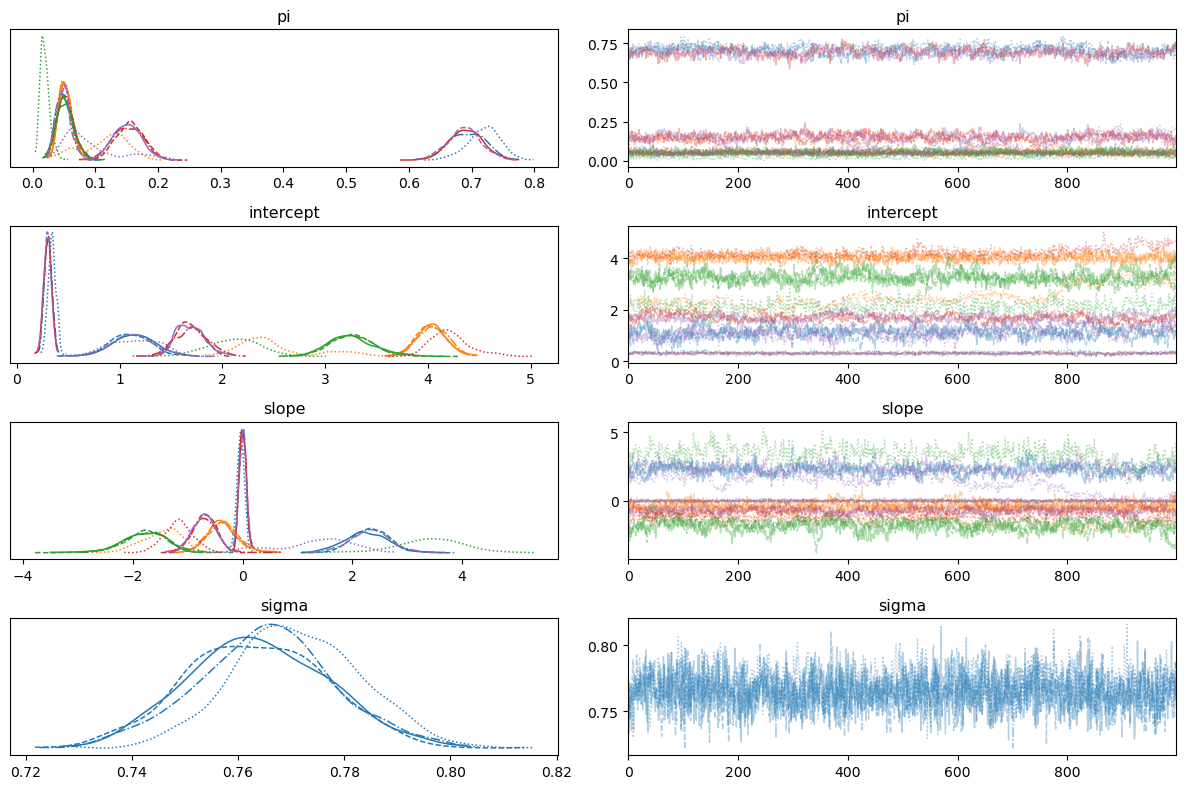

In [12]:
# --- Trace plots to visually inspect chain mixing ---
az.plot_trace(trace, var_names=["pi", "intercept", "slope", "sigma"])
plt.tight_layout()
plt.show()

In [13]:
# --- Posterior summary for growth parameters ---
az.summary(trace, var_names=["pi", "intercept", "slope", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi[0],0.379,0.329,0.026,0.743,0.163,0.005,6.0,60.0,1.82
pi[1],0.068,0.034,0.031,0.146,0.015,0.012,9.0,18.0,1.39
pi[2],0.045,0.019,0.009,0.075,0.007,0.002,8.0,29.0,1.49
pi[3],0.263,0.252,0.033,0.714,0.125,0.070,5.0,18.0,2.48
pi[4],0.245,0.260,0.032,0.710,0.129,0.072,5.0,33.0,2.30
intercept[0],0.721,0.425,0.236,1.374,0.199,0.008,6.0,53.0,1.83
intercept[1],3.659,0.699,2.196,4.331,0.336,0.218,7.0,15.0,1.57
intercept[2],2.972,0.553,1.804,3.685,0.251,0.136,7.0,29.0,1.53
intercept[3],1.974,1.422,0.222,4.338,0.705,0.366,5.0,16.0,2.51
intercept[4],1.064,0.529,0.234,1.802,0.250,0.109,5.0,32.0,2.36


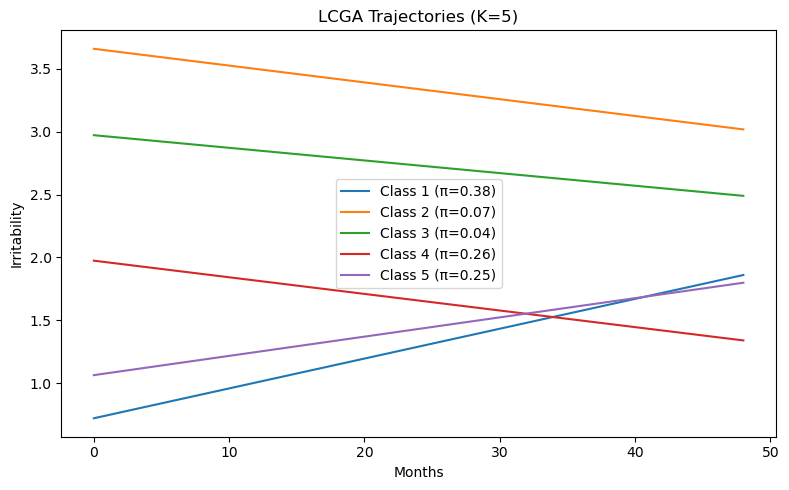

In [14]:
# --- Plot class trajectories ---
posterior = trace.posterior

inter_post = posterior["intercept"].mean(("chain", "draw")).values  # (K,)
slope_post = posterior["slope"].mean(("chain", "draw")).values       # (K,)
pi_post    = posterior["pi"].mean(("chain", "draw")).values          # (K,)

t_scaled = np.linspace(0, 1, 100)
t_months = t_scaled * 48

fig, ax = plt.subplots(figsize=(8, 5))
for k in range(K):
    traj = inter_post[k] + slope_post[k] * t_scaled
    ax.plot(t_months, traj, label=f"Class {k+1} (π={pi_post[k]:.2f})")

ax.set_xlabel("Months")
ax.set_ylabel("Irritability")
ax.set_title(f"LCGA Trajectories (K={K})")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# --- Class assignment ---
#
# FIX: the original code used post.mean().round() on a categorical variable,
# which is methodologically wrong and sensitive to label switching.
#
# Correct approach:
#   - Posterior mode = most frequently sampled class (hard assignment)
#   - Posterior class probabilities = proportion of samples in each class (soft assignment)
#
# Both are reported below.

post = trace.posterior["c"].stack(sample=("chain", "draw")).values  # (N, n_samples)

n_samples = post.shape[1]

# Hard assignment: posterior mode
class_mode = stats.mode(post, axis=1).mode.flatten()

# Soft assignment: probability of belonging to each class
class_probs = np.stack(
    [(post == k).sum(axis=1) / n_samples for k in range(K)],
    axis=1
)  # (N, K)

# Assemble results dataframe
class_df = pd.DataFrame(
    class_probs,
    columns=[f"prob_class_{k+1}" for k in range(K)]
)
class_df.insert(0, "id", ids)
class_df["assigned_class"] = class_mode + 1  # 1-indexed

print("Class distribution:")
print(class_df["assigned_class"].value_counts().sort_index())
print()
class_df.head(10)

Class distribution:
assigned_class
1    361
2     26
3     28
4     68
5     17
Name: count, dtype: int64



,id,prob_class_1,prob_class_2,prob_class_3,prob_class_4,prob_class_5,assigned_class
0,NDAR_INV010ZM3H9,0.01500,0.22375,0.49600,0.15325,0.1120,3
1,NDAR_INV01AJ15N9,0.49850,0.00000,0.00000,0.25150,0.2500,1
2,NDAR_INV02EBX0JJ,0.45650,0.00275,0.00700,0.04875,0.4850,5
3,NDAR_INV03XVEBPM,0.50000,0.00000,0.00000,0.25000,0.2500,1
4,NDAR_INV08J0E48V,0.50000,0.00000,0.00000,0.25000,0.2500,1
5,NDAR_INV08UNGWZK,0.00025,0.20725,0.69375,0.09675,0.0020,3
6,NDAR_INV09T2EBX4,0.50000,0.00000,0.00000,0.25000,0.2500,1
7,NDAR_INV0C7TZ6YW,0.00025,0.11175,0.73100,0.15700,0.0000,3
8,NDAR_INV0E1RBR9J,0.48875,0.00025,0.00000,0.26050,0.2505,1
9,NDAR_INV0G42TBW1,0.02050,0.21800,0.04150,0.47150,0.2485,4


Average classification entropy: 0.6579
(0 = perfect separation, 1 = no separation)


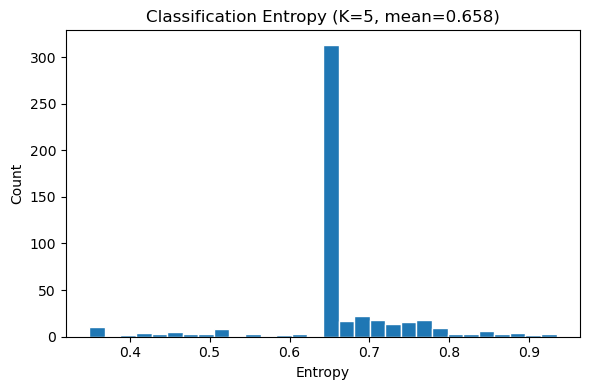

In [16]:
# --- Classification entropy ---
# Measures uncertainty in class assignment.
# Normalized to [0, 1]: 0 = perfect separation, 1 = no separation.

eps = 1e-10
entropy_per_person = -np.sum(
    class_probs * np.log(class_probs + eps), axis=1
) / np.log(K)

avg_entropy = entropy_per_person.mean()
print(f"Average classification entropy: {avg_entropy:.4f}")
print(f"(0 = perfect separation, 1 = no separation)")

plt.figure(figsize=(6, 4))
plt.hist(entropy_per_person, bins=30, edgecolor="white")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.title(f"Classification Entropy (K={K}, mean={avg_entropy:.3f})")
plt.tight_layout()
plt.show()

In [17]:
# --- Save class assignments ---
out_path = "lcga_class_assignments.csv"
class_df.to_csv(out_path, index=False)
print(f"Saved class assignments to {out_path}")

Saved class assignments to lcga_class_assignments.csv
